# Taller 3 - Agrupamiento k-means y jerárquico aglomerativo

## Desarrollo del método k-means

### Integrantes del grupo:

- Carlos Manuel Carvajales Castrillo
- Mateo Ruiz Mendoza

Este Notebook tiene como objetivo mostrar el desarrollo del taller aplicando el método **k-means** para el dataset **Drug Compsution**.

In [ ]:
# Se instala la librería ucimlrepo para acceder a los datasets de UCI Machine Learning Repository

!pip install ucimlrepo


[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Importar la función para obtener el dataset de consumo de drogas cuantificado

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
drug_consumption_quantified = fetch_ucirepo(id=373) 
  
# data (as pandas dataframes) 
X = drug_consumption_quantified.data.features 
y = drug_consumption_quantified.data.targets 
  
# metadata 
print(drug_consumption_quantified.metadata) 
  
# variable information 
print(drug_consumption_quantified.variables) 


{'uci_id': 373, 'name': 'Drug Consumption (Quantified)', 'repository_url': 'https://archive.ics.uci.edu/dataset/373/drug+consumption+quantified', 'data_url': 'https://archive.ics.uci.edu/static/public/373/data.csv', 'abstract': 'Classify type of drug consumer by personality data', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1885, 'num_features': 12, 'feature_types': ['Real'], 'demographics': ['Age', 'Gender', 'Education Level', 'Nationality', 'Ethnicity'], 'target_col': ['alcohol', 'amphet', 'amyl', 'benzos', 'caff', 'cannabis', 'choc', 'coke', 'crack', 'ecstasy', 'heroin', 'ketamine', 'legalh', 'lsd', 'meth', 'mushrooms', 'nicotine', 'semer', 'vsa'], 'index_col': ['id'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Fri Mar 08 2024', 'dataset_doi': '10.24432/C5TC7S', 'creators': ['Elaine Fehrman', 'Vincent Egan', 'Evgeny Mirkes'], 'intro_paper': {'ID': 413, 

In [ ]:
# Se realiza un describe de las columnas presentes en X

X.describe()

,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,impuslive,ss
count,1885.00000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000
mean,0.03461,-0.000256,-0.003806,0.355542,-0.309577,0.000047,-0.000163,-0.000534,-0.000245,-0.000386,0.007216,-0.003292
std,0.87836,0.482588,0.950078,0.700335,0.166226,0.998106,0.997448,0.996229,0.997440,0.997523,0.954435,0.963701
min,-0.95197,-0.482460,-2.435910,-0.570090,-1.107020,-3.464360,-3.273930,-3.273930,-3.464360,-3.464360,-2.555240,-2.078480
25%,-0.95197,-0.482460,-0.611130,-0.570090,-0.316850,-0.678250,-0.695090,-0.717270,-0.606330,-0.652530,-0.711260,-0.525930
50%,-0.07854,-0.482460,-0.059210,0.960820,-0.316850,0.042570,0.003320,-0.019280,-0.017290,-0.006650,-0.217120,0.079870
75%,0.49788,0.482460,0.454680,0.960820,-0.316850,0.629670,0.637790,0.723300,0.760960,0.584890,0.529750,0.765400
max,2.59171,0.482460,1.984370,0.960820,1.907250,3.273930,3.273930,2.901610,3.464360,3.464360,2.901610,1.921730


In [ ]:
# Se realiza un describe de las columnas presentes en y

y.describe()

,alcohol,amphet,amyl,benzos,caff,cannabis,choc,coke,crack,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
count,1885,1885,1885,1885,1885,1885,1885,1885,1885,1885,1885,1885,1885,1885,1885,1885,1885,1885,1885
unique,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,5,7
top,CL5,CL0,CL0,CL0,CL6,CL6,CL6,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL6,CL0,CL0
freq,759,976,1305,1000,1385,463,807,1038,1627,1021,1605,1490,1094,1069,1429,982,610,1877,1455


Note que los datos de X ya están normalizados, por lo que no se realiza ningún procesamiento adicional de los mismos.

Por su parte, **y**, al tener columnas con datos categóricos, si es necesario procesarlo. Para ello se procede a binarizar las categorías presentes de tal manera que 0 es **no consumidor** y 1 es **consumidor** de la siguiente forma:

- CL0, CL1, CL2 --> 0 (No consumidor)
- CL3, CL4, CL5, CL4 --> 1 (Consumidor)

Se definió como consumidor (1) a individuos con consumo reciente (último año o más reciente), ya que este tipo de consumo es más representativo del comportamiento actual del individuo. Los niveles CL0–CL2 se agruparon como no consumidores (0), al reflejar ausencia de consumo o consumo no reciente.

In [52]:
# Importar las librerías necesarias para el análisis y modelado

from sklearn.cluster import KMeans
import pandas as pd
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [ ]:
# Se crean copias de X e y para realizar modificaciones sin afectar los datos originales

X_copy = X.copy()
y_copy = y.copy()

In [62]:
# Función para binarizar las clases de consumo de drogas, donde 'CL0', 'CL1' y 'CL2' se consideran no consumidores (0) y el resto se consideran consumidores (1)

def binarizar(col):
    return col.apply(lambda x: 0 if x in ['CL0', 'CL1', 'CL2'] else 1)

y_bin = y_copy.apply(binarizar)

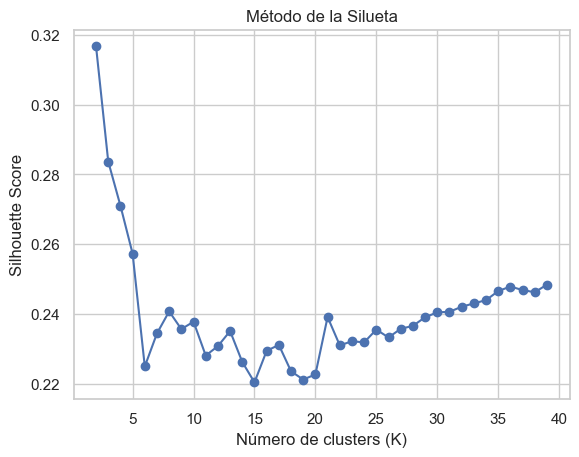

In [99]:
# Se aplica el método de la silueta para determinar el número óptimo de clusters (K) para el algoritmo K-Means

scores = []
K_range = range(2, 40)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_copy)
    score = silhouette_score(X_copy, labels)
    scores.append(score)

plt.figure()
plt.plot(K_range, scores, marker='o')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Método de la Silueta")
plt.show()

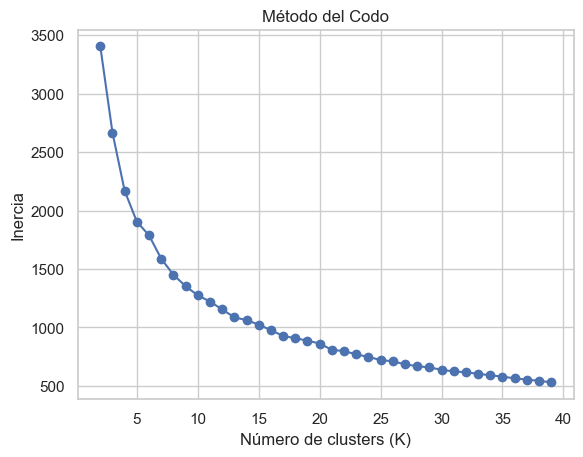

In [100]:
inertia = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_copy)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

Para escoger el número de clústeres se usaron el coeficiente de silueta y el método del codo. Por un lado, la silueta mostró claramente que $K=2$ es la mejor opción, indicando que los datos se separan de forma bastante limpia en dos grupos principales. Por otro lado, el método del codo no mostró un punto claro donde la mejora se detenga, sino una disminución gradual de la inercia a medida que aumenta $K$. Esto muestra que los datos no tienen una división natural en muchos grupos, sino que más bien representan un continuo de perfiles. En conjunto, esto respalda usar $K=2$ como una solución simple y bien fundamentada, aunque también se pueden explorar valores mayores para entender mejor posibles diferencias más finas entre los individuos. En ese sentido, además de probar con $K=2$, se prueba tambipen con $K=3$.

## Implementación de función para realizar clustering con K-MEANS

Esta función recibe el conjunto de datos $X$, $y_bin$ u el número de clústeres deseados $k$.

In [ ]:
def clustering_analysis_full(X, y_bin, k):
    from sklearn.cluster import KMeans
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import math

    sns.set(style="whitegrid")

    # ===== 1. Variables para clustering =====
    cols_cluster = ['nscore','escore','oscore','ascore','cscore','impuslive','ss']
    X_cluster = X.copy()

    # ===== 2. K-means =====
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_cluster)

    # ===== 3. Data base =====
    X_copy = X.copy()
    X_copy['cluster'] = clusters

    df = pd.concat([X_copy, y_bin], axis=1)

    # ===== 4. MAPEO (SOLO PARA INTERPRETAR) =====
    age_map = {
        -0.95197: "18-24", -0.07854: "25-34", 0.49788: "35-44",
        1.09449: "45-54", 1.82213: "55-64", 2.59171: "65+"
    }

    gender_map = {0.48246: "Mujer", -0.48246: "Hombre"}

    education_map = {
        -2.43591: "<16", -1.73790: "16", -1.43719: "17", -1.22751: "18",
        -0.61113: "Sin título", -0.05921: "Diploma", 0.45468: "Universitario",
        1.16365: "Maestría", 1.98437: "Doctorado"
    }

    country_map = {
        -0.09765: "Australia", 0.24923: "Canadá", -0.46841: "NZ",
        -0.28519: "Otros", 0.21128: "Irlanda", 0.96082: "UK", -0.57009: "USA"
    }

    ethnicity_map = {
        -0.50212: "Asiático", -1.10702: "Negro", 1.90725: "Negro/Asiático",
        0.12600: "Blanco/Asiático", -0.22166: "Blanco/Negro",
        0.11440: "Otros", -0.31685: "Blanco"
    }

    # Redondeo para evitar errores
    X_copy['age_cat'] = X_copy['age'].round(5).map(age_map)
    X_copy['gender_cat'] = X_copy['gender'].round(5).map(gender_map)
    X_copy['education_cat'] = X_copy['education'].round(5).map(education_map)
    X_copy['country_cat'] = X_copy['country'].round(5).map(country_map)
    X_copy['ethnicity_cat'] = X_copy['ethnicity'].round(5).map(ethnicity_map)

    # ===== 5. Boxplots psicométricos =====
    cols_psico = cols_cluster

    n_cols = 3
    n_rows = math.ceil(len(cols_psico)/n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
    axes = axes.flatten()

    for i, col in enumerate(cols_psico):
        sns.boxplot(x='cluster', y=col, data=X_copy, ax=axes[i])
        axes[i].set_title(col)

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    # ===== 6. Barras consumo =====
    consumo = df.groupby('cluster')[y_bin.columns].mean().reset_index()
    consumo_melt = consumo.melt(id_vars='cluster', var_name='droga', value_name='prop')

    plt.figure(figsize=(14,6))
    sns.barplot(data=consumo_melt, x='droga', y='prop', hue='cluster')
    plt.xticks(rotation=45)
    plt.title("Consumo por cluster")
    plt.show()

    # ===== 7. Sociodemográficas =====
        # ===== 7. Sociodemográficas (MEJORADO) =====
    cols_cat = ['age_cat','gender_cat','education_cat','country_cat','ethnicity_cat']

    n_cols = 1   # clave: una por fila (más espacio)
    n_rows = len(cols_cat)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))

    # Si solo hay un eje, convertir a lista
    if n_rows == 1:
        axes = [axes]

    for i, col in enumerate(cols_cat):
        sns.countplot(x=col, hue='cluster', data=X_copy, ax=axes[i])
        
        axes[i].set_title(f"{col} por cluster", fontsize=12)
        axes[i].tick_params(axis='x', rotation=45)
        
        # Ajuste de etiquetas largas
        for label in axes[i].get_xticklabels():
            label.set_horizontalalignment('right')

    plt.tight_layout()
    plt.show()

    return X_copy, df

## k=2 Clústeres

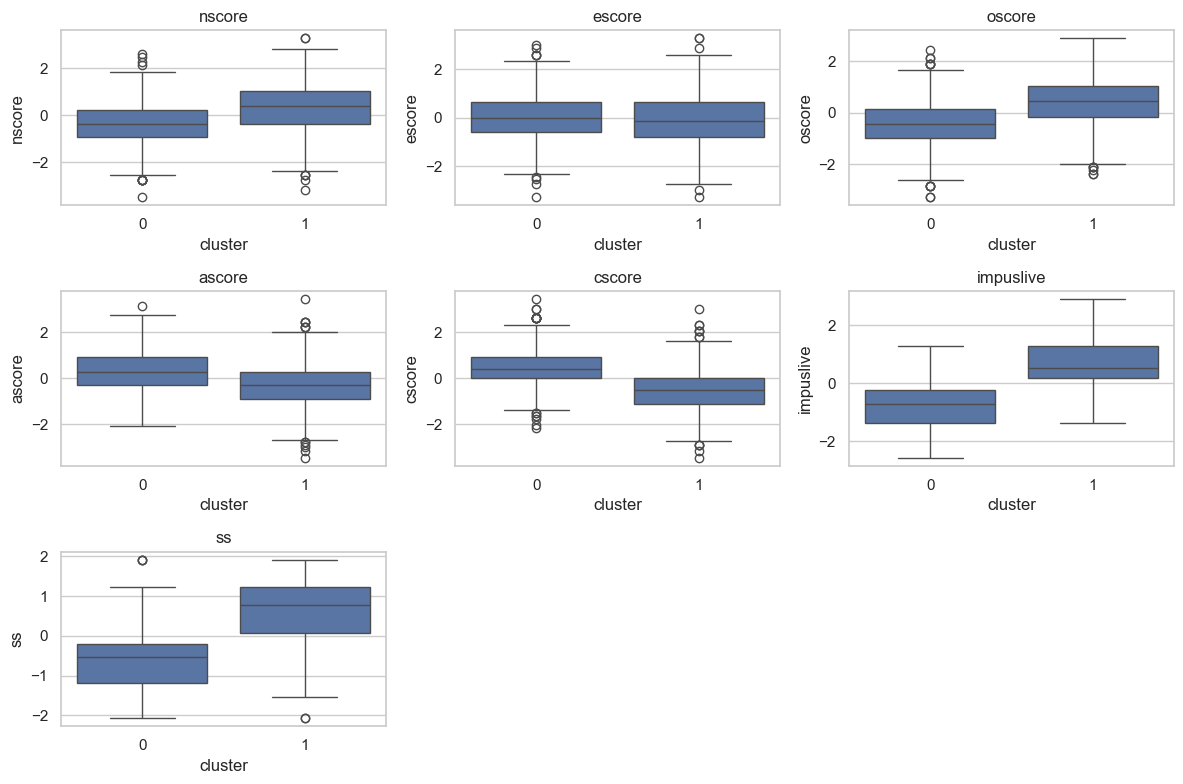

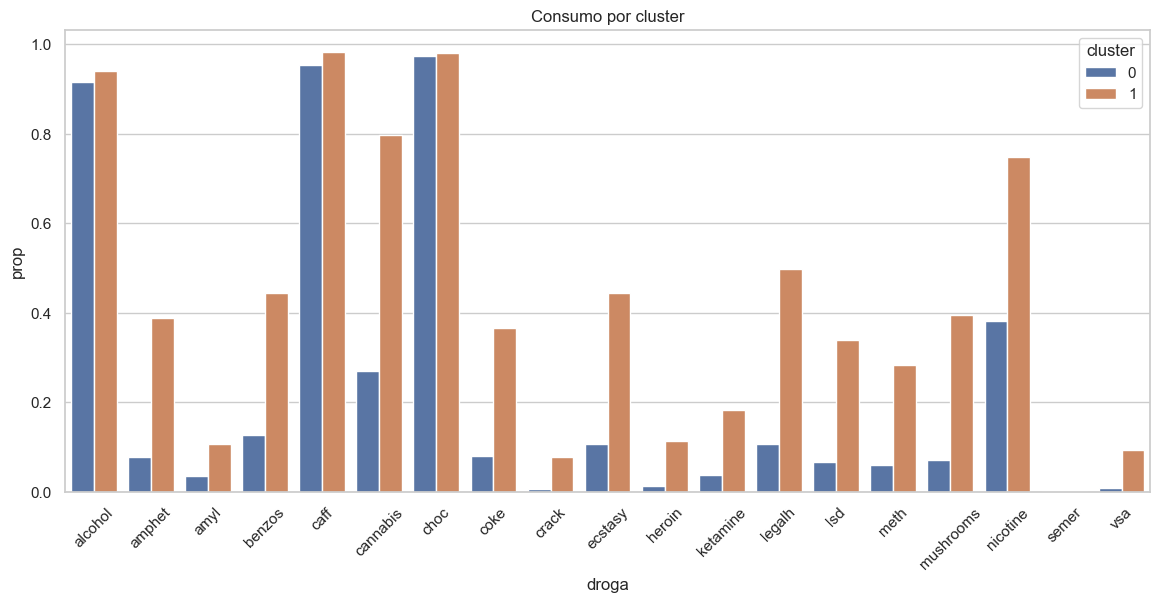

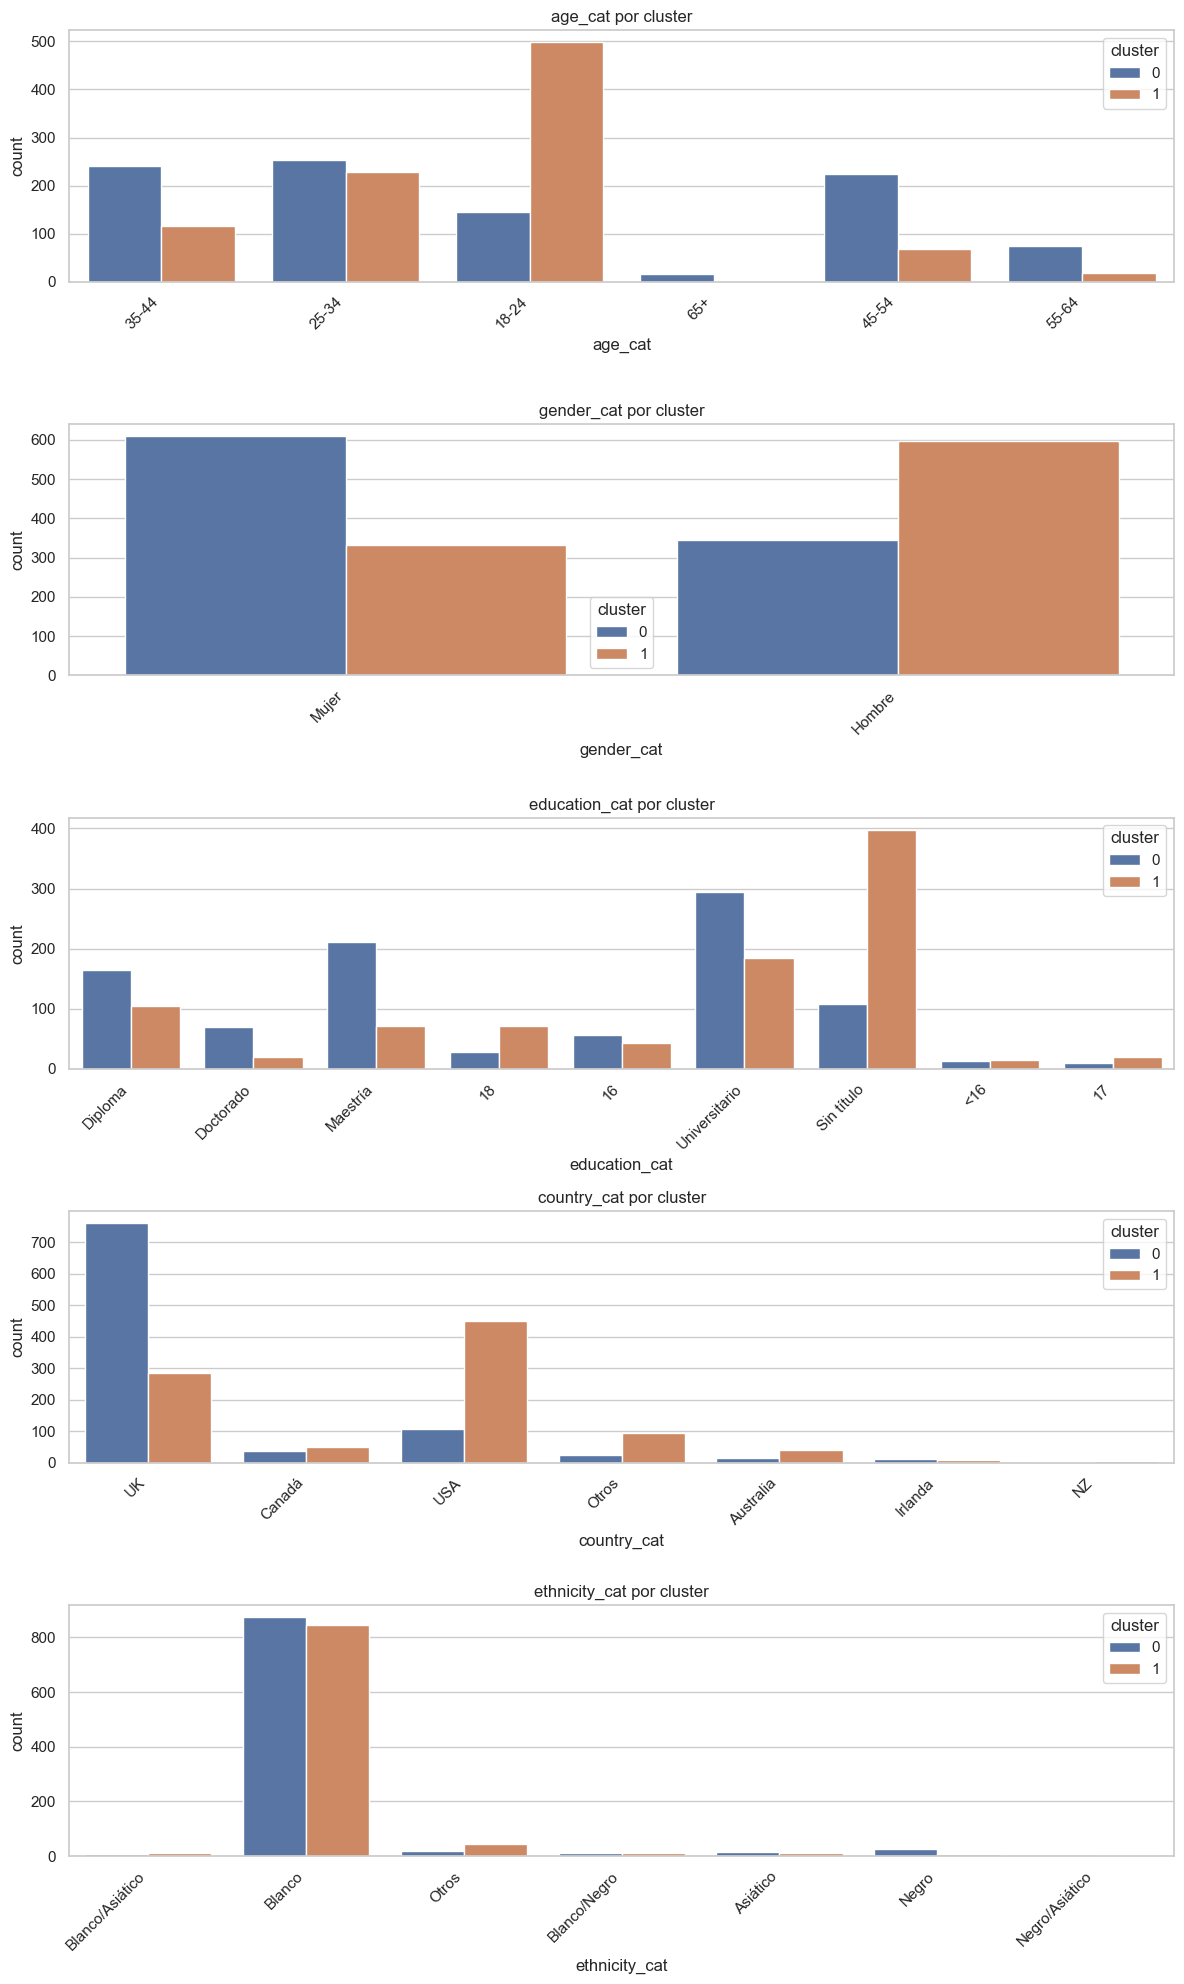

In [137]:
X_clustered, df = clustering_analysis_full(X, y_bin, k=2)

In [131]:
df.groupby('cluster')[y_bin.columns].mean()

,alcohol,amphet,amyl,benzos,caff,cannabis,choc,coke,crack,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
cluster,,,,,,,,,,,,,,,,,,,
0,0.915767,0.096112,0.035637,0.142549,0.954644,0.315335,0.975162,0.098272,0.009719,0.136069,0.019438,0.049676,0.136069,0.097192,0.076674,0.103672,0.402808,0.001080,0.015119
1,0.939520,0.361835,0.104275,0.420229,0.980188,0.737226,0.977059,0.339937,0.072993,0.407716,0.104275,0.168926,0.456726,0.302398,0.259645,0.352450,0.716371,0.002086,0.084463


In [138]:
X_clustered.groupby('cluster')[['nscore','escore','oscore','ascore','cscore','impuslive','ss']].mean()

,nscore,escore,oscore,ascore,cscore,impuslive,ss
cluster,,,,,,,
0,-0.327222,0.066442,-0.395183,0.309443,0.495233,-0.553519,-0.602176
1,0.336113,-0.068559,0.404723,-0.318258,-0.509328,0.583025,0.611692


In [140]:
X_clustered['cluster'].value_counts(normalize=True)

cluster
0    0.506631
1    0.493369
Name: proportion, dtype: float64

In [ ]:
pd.crosstab(X_clustered['cluster'], X_clustered['gender_cat'], normalize='index')

gender_cat,Hombre,Mujer
cluster,,
0,0.361257,0.638743
1,0.643011,0.356989


In [143]:
pd.crosstab(X_clustered['cluster'], X_clustered['age_cat'], normalize='index')

age_cat,18-24,25-34,35-44,45-54,55-64,65+
cluster,,,,,,
0,0.151832,0.264921,0.251309,0.235602,0.078534,0.017801
1,0.535484,0.245161,0.124731,0.074194,0.019355,0.001075


In [144]:
pd.crosstab(X_clustered['cluster'], X_clustered['education_cat'], normalize='index')

education_cat,16,17,18,<16,Diploma,Doctorado,Maestría,Sin título,Universitario
cluster,,,,,,,,,
0,0.058639,0.010471,0.029319,0.013613,0.172775,0.072251,0.220942,0.113089,0.308901
1,0.046237,0.021505,0.077419,0.016129,0.112903,0.021505,0.077419,0.427957,0.198925


In [146]:
df[df['cluster']==1][y_bin.columns].mean().sort_values(ascending=False)

caff         0.982796
choc         0.979570
alcohol      0.940860
cannabis     0.797849
nicotine     0.747312
legalh       0.496774
ecstasy      0.445161
benzos       0.444086
mushrooms    0.394624
amphet       0.388172
coke         0.365591
lsd          0.339785
meth         0.282796
ketamine     0.183871
heroin       0.112903
amyl         0.107527
vsa          0.092473
crack        0.078495
semer        0.002151
dtype: float64

### Análisis de reusltados para k=2

La segmentación mediante K-means con K=2 permitió identificar dos gruops de tamaño similar dentro de la población analizada, lo que facilita una comparación equilibrada entre perfiles. El primer grupo (cluster 0) se caracteriza por individuos con bajos niveles de neuroticismo, impulsividad y búsqueda de sensaciones, junto con valores elevados en responsabilidad y amabilidad. Este conjunto de rasgos sugiere un perfil emocionalmente estable y con mayor control conductual. En términos de consumo, este grupo presenta niveles bajos en la mayoría de las sustancias, limitándose principalmente a aquellas socialmente aceptadas como el alcohol, la cafeína y el chocolate, mientras que el consumo de drogas ilegales es considerablemente reducido. Desde el punto de vista sociodemográfico, este cluster está compuesto en mayor proporción por mujeres, con una distribución de edad más madura y un nivel educativo relativamente alto, lo que sugiere la presencia de factores protectores frente al consumo.

Por otro lado, el segundo grupo (cluster 1) presenta un perfil marcadamente distinto, caracterizado por mayores niveles de impulsividad, búsqueda de sensaciones, neuroticismo y apertura a la experiencia, junto con menores niveles de responsabilidad y amabilidad. Este patrón psicológico se asocia con una mayor predisposición a conductas de riesgo, lo cual se refleja en un consumo significativamente más alto y diversificado de sustancias. En este grupo se observa un claro patrón de policonsumo, destacándose el uso de cannabis, nicotina, cocaína, éxtasis y benzodiacepinas, entre otras. A nivel sociodemográfico, este cluster está compuesto mayoritariamente por hombres jóvenes, especialmente en el rango de 18 a 34 años, y presenta una mayor proporción de individuos sin título educativo formal, lo que podría estar relacionado con una mayor vulnerabilidad frente al consumo.

En conjunto, los resultados evidencian que el consumo de sustancias no es un fenómeno homogéneo, sino que está fuertemente influenciado por la interacción entre rasgos de personalidad y características sociodemográficas. En particular, la impulsividad y la búsqueda de sensaciones emergen como factores clave asociados a mayores niveles de consumo, mientras que la responsabilidad y la estabilidad emocional parecen actuar como elementos protectores. Asimismo, variables como la edad, el género y el nivel educativo refuerzan estas diferencias, permitiendo identificar perfiles claramente diferenciados y facilitando una mejor comprensión de los patrones de comportamiento en la población estudiada.

## k=3 Clústeres

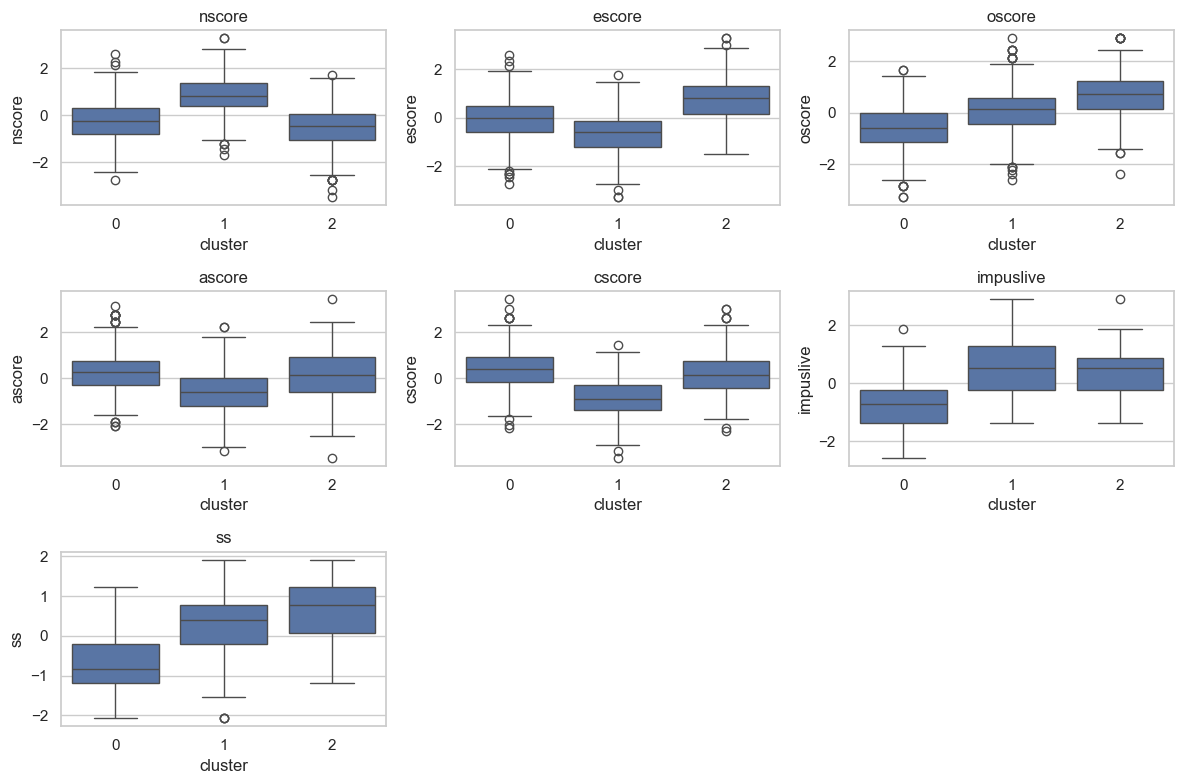

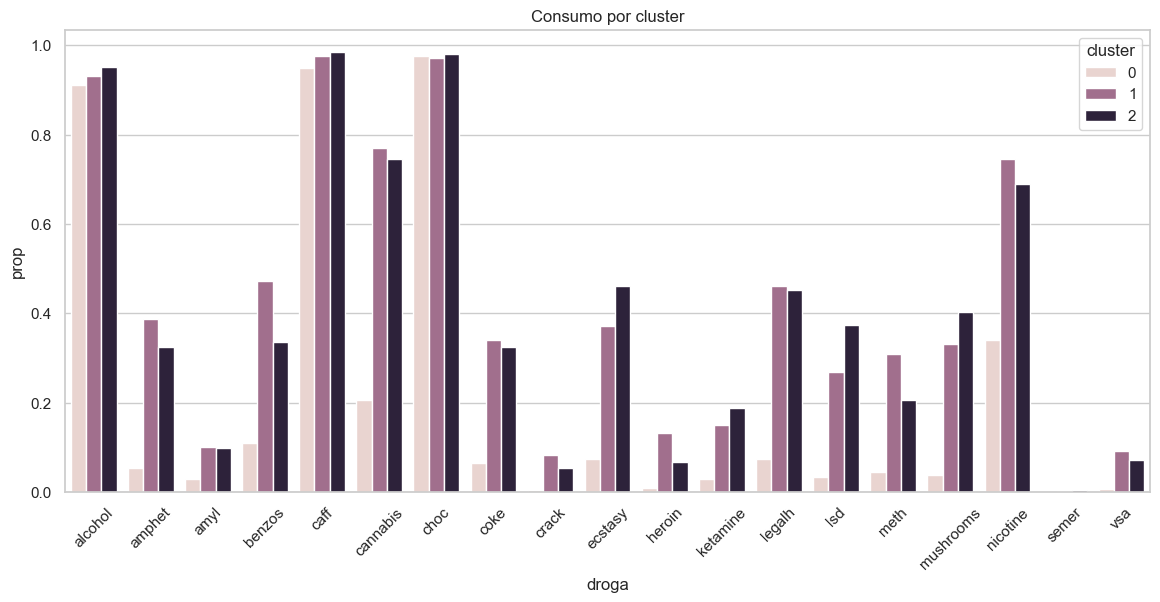

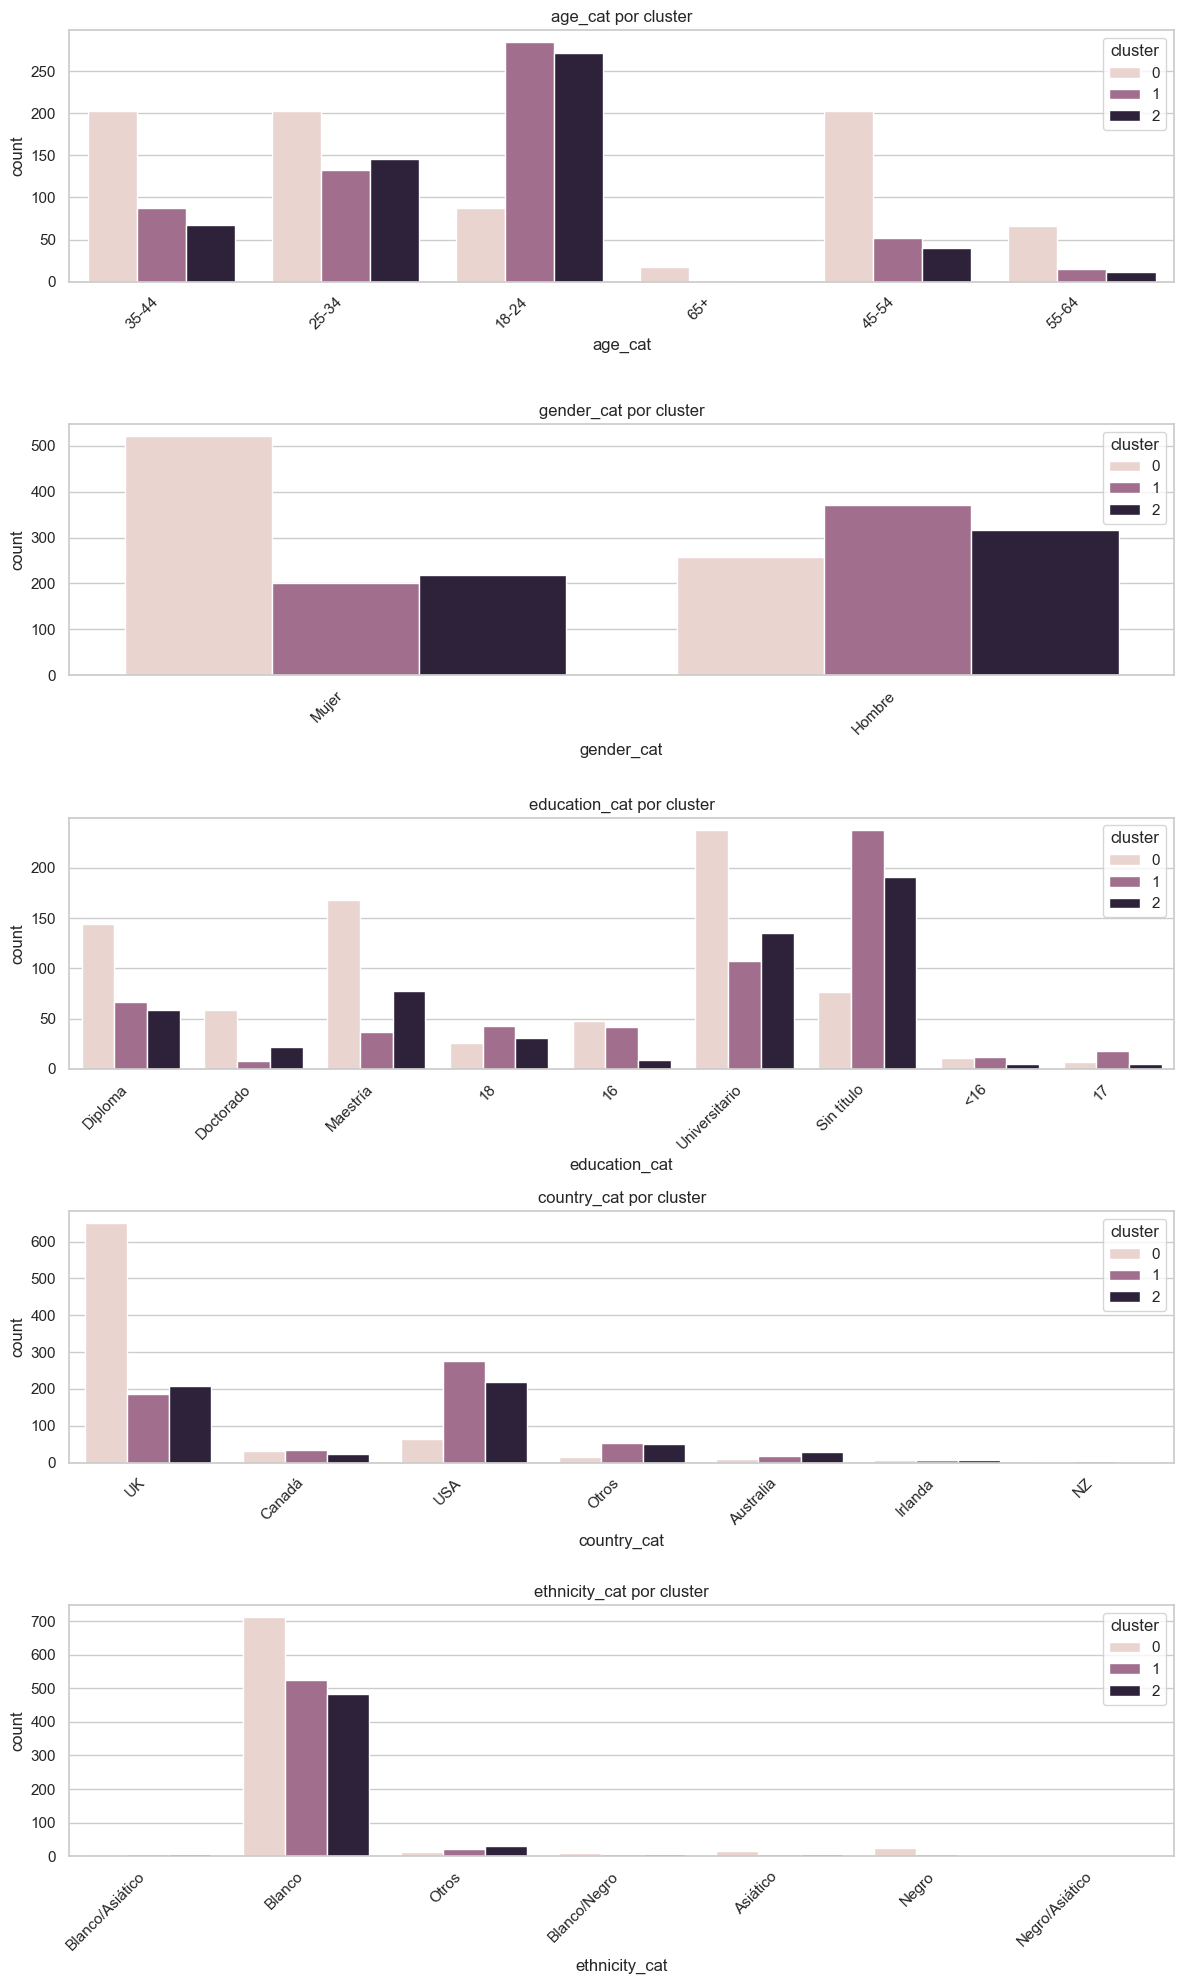

In [147]:
X_clustered, df = clustering_analysis_full(X, y_bin, k=3)

In [148]:
df.groupby('cluster')[y_bin.columns].mean()

,alcohol,amphet,amyl,benzos,caff,cannabis,choc,coke,crack,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
cluster,,,,,,,,,,,,,,,,,,,
0,0.910026,0.052699,0.029563,0.109254,0.949871,0.205656,0.975578,0.064267,0.005141,0.074550,0.007712,0.028278,0.074550,0.033419,0.043702,0.038560,0.340617,0.000000,0.006427
1,0.930070,0.388112,0.099650,0.472028,0.975524,0.769231,0.972028,0.339161,0.082168,0.372378,0.132867,0.150350,0.461538,0.269231,0.307692,0.330420,0.744755,0.001748,0.090909
2,0.951402,0.323364,0.099065,0.336449,0.985047,0.745794,0.981308,0.323364,0.052336,0.459813,0.067290,0.186916,0.452336,0.373832,0.205607,0.401869,0.689720,0.003738,0.071028


In [149]:
X_clustered.groupby('cluster')[['nscore','escore','oscore','ascore','cscore','impuslive','ss']].mean()

,nscore,escore,oscore,ascore,cscore,impuslive,ss
cluster,,,,,,,
0,-0.250376,-0.061818,-0.553300,0.284105,0.466940,-0.646409,-0.765683
1,0.847031,-0.657934,0.076454,-0.545748,-0.840789,0.510421,0.399292
2,-0.541349,0.792758,0.720988,0.169481,0.218551,0.419715,0.674956


In [150]:
X_clustered['cluster'].value_counts(normalize=True)

cluster
0    0.412732
1    0.303448
2    0.283820
Name: proportion, dtype: float64

In [151]:
pd.crosstab(X_clustered['cluster'], X_clustered['gender_cat'], normalize='index')

gender_cat,Hombre,Mujer
cluster,,
0,0.330334,0.669666
1,0.646853,0.353147
2,0.590654,0.409346


In [153]:
pd.crosstab(X_clustered['cluster'], X_clustered['age_cat'], normalize='index')

age_cat,18-24,25-34,35-44,45-54,55-64,65+
cluster,,,,,,
0,0.113111,0.260925,0.259640,0.259640,0.084833,0.021851
1,0.496503,0.232517,0.152098,0.090909,0.026224,0.001748
2,0.506542,0.271028,0.125234,0.074766,0.022430,0.000000


In [154]:
pd.crosstab(X_clustered['cluster'], X_clustered['education_cat'], normalize='index')

education_cat,16,17,18,<16,Diploma,Doctorado,Maestría,Sin título,Universitario
cluster,,,,,,,,,
0,0.061697,0.008997,0.033419,0.014139,0.185090,0.075835,0.215938,0.098972,0.305913
1,0.073427,0.031469,0.075175,0.020979,0.117133,0.013986,0.064685,0.416084,0.187063
2,0.016822,0.009346,0.057944,0.009346,0.110280,0.041121,0.145794,0.357009,0.252336


In [155]:
df[df['cluster']==1][y_bin.columns].mean().sort_values(ascending=False)

caff         0.975524
choc         0.972028
alcohol      0.930070
cannabis     0.769231
nicotine     0.744755
benzos       0.472028
legalh       0.461538
amphet       0.388112
ecstasy      0.372378
coke         0.339161
mushrooms    0.330420
meth         0.307692
lsd          0.269231
ketamine     0.150350
heroin       0.132867
amyl         0.099650
vsa          0.090909
crack        0.082168
semer        0.001748
dtype: float64

### Análisis de resultados para k=3

La aplicación del algoritmo K-means con K=3 permitió identificar tres grupos diferenciados dentro de la población, evidenciando una segmentación más rica que la obtenida con dos clústeres. En términos de distribución, el cluster 0 agrupa el 41.3% de los individuos, mientras que los clusters 1 y 2 representan el 30.3% y 28.4% respectivamente, lo que indica una partición relativamente equilibrada. Esta configuración no solo separa a los individuos en función de su nivel de consumo, sino que además distingue entre diferentes tipos de comportamiento dentro de los consumidores.

El cluster 0 se caracteriza por individuos con bajos niveles de impulsividad, búsqueda de sensaciones y apertura a la experiencia, junto con niveles relativamente altos de responsabilidad. Este perfil psicológico sugiere un mayor control conductual y una menor propensión al riesgo. En concordancia con estos rasgos, el consumo de sustancias en este grupo es bajo en casi todas las categorías, limitándose principalmente a sustancias socialmente aceptadas como el alcohol, la cafeína y el chocolate. Desde el punto de vista sociodemográfico, este cluster presenta una mayor proporción de mujeres, así como una distribución de edad más madura y niveles educativos más altos, lo que sugiere la presencia de factores protectores frente al consumo.

Por su parte, el cluster 1 presenta un perfil marcdamente distinto, caracterizado por altos niveles de neuroticismo, impulsividad y baja responsabilidad. Este conjunto de rasgos está asociado con una mayor vulnerabilidad emocional y menor capacidad de regulación conductual. En términos de consumo, este grupo exhibe un patrón de policonsumo, con altas tasas en sustancias como cannabis, nicotina, benzodiacepinas y estimulantes. Este patrón sugiere un posible uso de sustancias como mecanismo de regulación emocional. Adicionalmente, este cluster está compuesto mayoritariamente por hombres jóvenes, con una alta proporción de individuos sin formación académica formal, lo que refuerza la idea de un perfil de mayor riesgo.

Finalmente, el cluster 2 agrupa individuos con altos niveles de extraversión, apertura a la experiencia y búsqueda de sensaciones, junto con niveles moderados de impulsividad. A diferencia del cluster anterior, este perfil está más asociado a la exploración y la interacción social. El consumo de sustancias en este grupo se concentra en drogas típicamente vinculadas a contextos recreativos, como el cannabis, el éxtasis, el LSD y los hongos, lo que sugiere un patrón de consumo más experimental que problemático. Desde el punto de vista sociodemográfico, este cluster también está compuesto principalmente por individuos jóvenes, con una proporción importante de hombres y niveles educativos intermedios.

En conjunto, los resultados evidencian que el consumo de sustancias no solo depende de la intensidad, sino también del tipo de perfil psicológico del individuo. Mientras que algunos grupos presentan un consumo asociado a factores de riesgo y vulnerabilidad emocional, otros reflejan patrones más ligados a la exploración y el contexto social. Esta diferenciación permite una comprensión más profunda del fenómeno, destacando la importancia de considerar tanto variables psicométricas como sociodemográficas en el análisis del comportamiento de consumo.

En conclusión, la elección del número de clusters no debe basarse únicamente en métricas cuantitativas como la silueta, sino también en la capacidad del modelo para capturar patrones significativos dentro de los datos. En este caso, K=3 proporciona una segmentación más informativa, permitiendo una mejor comprensión de la heterogeneidad en los patrones de consumo y facilitando la identificación de perfiles diferenciados dentro de la población analizada.